<a href="https://colab.research.google.com/github/baynobu/PCVK-Ganjil-26/blob/main/P5_01_Abdul_Rahman_Hanif_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAPORAN PRAKTIKUM MINGGU 5
## PENGOLAHAN CITRA DAN VISI KOMPUTER
### Topik: Histogram, Histogram Equalization, dan Dithering

* **Nama Mahasiswa** : Abdul Rahman Hanif Darmawan
* **NIM** : 244107020232
* **No. Presensi** : 01
* **Program Studi** : D-IV Teknik Informatika
* **Jurusan** : Teknologi Informasi - Politeknik Negeri Malang


In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Abdul Rahman Hanif Darmawan'
NIM = '244107020232' # ganti dengan NIM Anda jika berbeda
N = int(NIM[-3:])

PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}

try:
    waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
except Exception:
    waktu = datetime.datetime.now()

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA   : Abdul Rahman Hanif Darmawan
NIM    : 244107020232 | N = 232
bins   : 8
clip   : 2.0
tile   : 2
L      : 4
WAKTU  : 2026-09-22 15:33:02 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 9ec1b0acc59e7b50


## Inisialisasi Library dan Direktori Penyimpanan Citra
Sesuai instruksi modul:
* `CONTOH`: direktori penyimpanan citra bersama (`lena.jpg`, `lena_lc.jpg`).
* `BASE`: direktori penyimpanan citra KTM pribadi (`KTM1a.jpg`, `KTM1b.jpg`, `KTM1c.jpg`, `KTM1d.jpg`).
* Kode di bawah ini secara adaptif mendeteksi lingkungan Google Colab maupun eksekusi lokal.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

CONTOH_COLAB = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/'
BASE_COLAB = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/' + NIM

CONTOH = CONTOH_COLAB if os.path.exists(CONTOH_COLAB) else '.'
BASE = BASE_COLAB if os.path.exists(BASE_COLAB) else '.'

def get_image_path(filename, directory):
    """Membantu menemukan path file citra baik di folder Drive target maupun direktori kerja lokal."""
    target = os.path.join(directory, filename)
    if os.path.exists(target):
        return target
    if os.path.exists(filename):
        return filename
    return target

print("Path CONTOH :", CONTOH)
print("Path BASE   :", BASE)


Path CONTOH : /content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/
Path BASE   : .


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# E-1 PERCOBAAN HISTOGRAM

Histogram citra merupakan representasi grafis frekuensi kemunculan setiap nilai intensitas piksel pada citra digital.
* Sumbu horizontal mewakili nilai intensitas piksel ($[0, L-1]$).
* Sumbu vertikal mewakili jumlah piksel (frekuensi kemunculan).

Berikut adalah implementasi fungsi `histogram_manual` sesuai algoritma perulangan bertingkat pada modul.


In [ ]:
def histogram_manual(img, L=256):
    """
    Menghitung histogram citra 2D (grayscale) secara manual
    menggunakan perulangan bertingkat (baris dan kolom).
    """
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h


### E-1 Langkah 3 Tahap 1: Verifikasi dengan Citra Contoh (`lena.jpg`)
Pada tahap ini, kita memverifikasi kebenaran fungsi `histogram_manual` pada citra grayscale dan citra berwarna kanal B, G, R.


<BarContainer object of 256 artists>

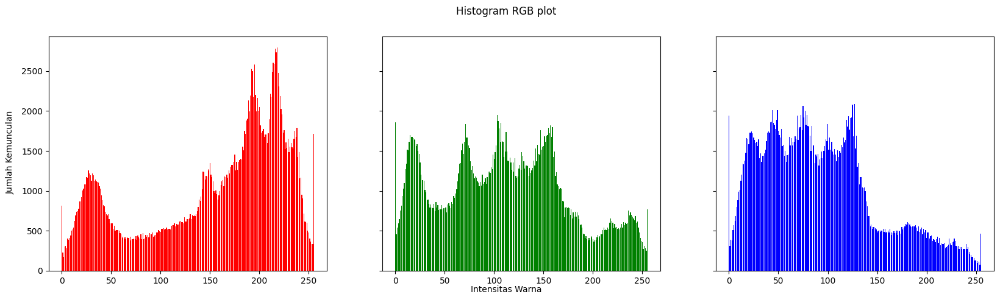

In [ ]:
# membuat histogram image (manual)
img = cv.imread(
    '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena.jpg'
)
assert img is not None, "File ktm1a tidak ditemukan!"
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
  for x in range(0, width):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

### E-1 Langkah 3 Tahap 2: Penerapan pada Citra Pribadi (`KTM1b.jpg`)
Menerapkan proses yang sama pada citra KTM pribadi dengan kondisi pencahayaan lampu ruangan (`KTM1b.jpg`).


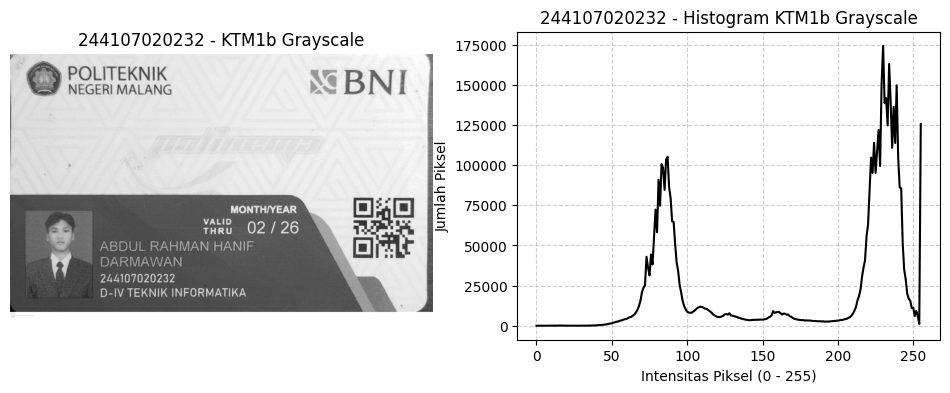

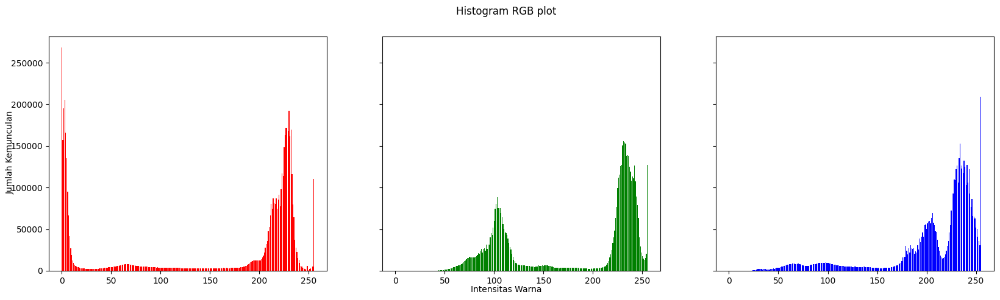

In [ ]:
path_ktm1b = get_image_path('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1b.jpg', BASE)
gray_ktm1b = cv.imread(path_ktm1b, cv.IMREAD_GRAYSCALE)
bgr_ktm1b = cv.imread(path_ktm1b)

if gray_ktm1b is not None and bgr_ktm1b is not None:
  h_ktm1b = histogram_manual(gray_ktm1b)
  p_ktm1b = h_ktm1b / gray_ktm1b.size
  cdf_ktm1b = np.cumsum(p_ktm1b)
  assert (
      h_ktm1b.sum() == gray_ktm1b.size
  ), "Pemeriksaan wajib: jumlah histogram harus sama dengan total piksel!"

  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.imshow(gray_ktm1b, cmap='gray')
  plt.title(f'{NIM} - KTM1b Grayscale')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.plot(h_ktm1b, color='black', linewidth=1.5)
  plt.title(f'{NIM} - Histogram KTM1b Grayscale')
  plt.xlabel('Intensitas Piksel (0 - 255)')
  plt.ylabel('Jumlah Piksel')
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()

  rgb_ktm1b = cv.cvtColor(bgr_ktm1b, cv.COLOR_BGR2RGB)

  names = np.arange(256)
  red_hist = histogram_manual(rgb_ktm1b[:, :, 0])
  green_hist = histogram_manual(rgb_ktm1b[:, :, 1])
  blue_hist = histogram_manual(rgb_ktm1b[:, :, 2])

  fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
  fig.suptitle('Histogram RGB plot')
  fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
  fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

  axs[0].bar(names, red_hist, color='red')
  axs[1].bar(names, green_hist, color='green')
  axs[2].bar(names, blue_hist, color='blue')
  plt.show()

else:
  print(f'Berkas citra KTM1b.jpg belum tersedia di {path_ktm1b}')

## PERTANYAAN PRAKTIKUM E1

### Pertanyaan 1:
> Buatlah histogram citra yang sama menggunakan library NumPy (`numpy.histogram`) dan OpenCV (`cv.calcHist`). Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada `lena.jpg` lebih dulu, kemudian ulangi pada `KTM1b.jpg`.


In [ ]:
def verifikasi_histogram_tiga_metode(img, nama_citra):
  h_manual = histogram_manual(img)

  h_numpy, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])

  h_cv = (
      cv.calcHist([img], [0], None, [256], [0, 256]).flatten().astype(np.int64)
  )

  diff_manual_numpy = np.max(np.abs(h_manual - h_numpy))
  diff_manual_cv = np.max(np.abs(h_manual - h_cv))
  diff_numpy_cv = np.max(np.abs(h_numpy - h_cv))

  print(f'=== Hasil Pengujian Tiga Metode Histogram: {nama_citra} ===')
  print(f'Max Diff (Manual vs NumPy) : {diff_manual_numpy}')
  print(f'Max Diff (Manual vs OpenCV): {diff_manual_cv}')
  print(f'Max Diff (NumPy vs OpenCV) : {diff_numpy_cv}')

  assert (
      diff_manual_numpy == 0 and diff_manual_cv == 0 and diff_numpy_cv == 0
  ), 'Selisih ketiga metode harus nol!'
  print(
      '>> KESIMPULAN: Selisih bernilai 0 sempurna! Ketiga metode menghasilkan'
      ' histogram yang identik.\n'
  )


path_lena = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena.jpg'
gray_lena = cv.imread(path_lena, cv.IMREAD_GRAYSCALE)

if gray_lena is not None:
  verifikasi_histogram_tiga_metode(gray_lena, path_lena)
else:
  print(f'Citra lena tidak ditemukan di {path_lena}')

if 'gray_ktm1b' in locals() and gray_ktm1b is not None:
  verifikasi_histogram_tiga_metode(
      gray_ktm1b, '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1b.jpg'
  )
else:
  print('Variabel gray_ktm1b belum dimuat atau tidak ditemukan.')

=== Hasil Pengujian Tiga Metode Histogram: /content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena.jpg ===
Max Diff (Manual vs NumPy) : 0
Max Diff (Manual vs OpenCV): 0
Max Diff (NumPy vs OpenCV) : 0
>> KESIMPULAN: Selisih bernilai 0 sempurna! Ketiga metode menghasilkan histogram yang identik.

=== Hasil Pengujian Tiga Metode Histogram: /content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1b.jpg ===
Max Diff (Manual vs NumPy) : 0
Max Diff (Manual vs OpenCV): 0
Max Diff (NumPy vs OpenCV) : 0
>> KESIMPULAN: Selisih bernilai 0 sempurna! Ketiga metode menghasilkan histogram yang identik.



**Analisis Jawaban Pertanyaan 1:**
Berdasarkan hasil perhitungan selisih maksimum mutlak antar ketiga metode (`histogram_manual`, `numpy.histogram`, dan `cv.calcHist`):
* Nilai selisih maksimum pada citra `lena.jpg` dan `KTM1b.jpg` bernilai **0**.
* Hal ini membuktikan bahwa algoritma manual yang dibangun menggunakan perulangan bertingkat memiliki logika pembacaan dan pencacahan frekuensi intensitas piksel yang identik dengan implementasi pustaka bawaan NumPy dan OpenCV yang telah teroptimasi secara terkompilasi C/C++ di tingkat rendah.


### Pertanyaan 2:
> Gambarkan histogram ternormalisasi $p(j)$ dan kurva CDF untuk `KTM1a.jpg` sampai `KTM1d.jpg` dalam satu figure $2 \times 2$. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2.


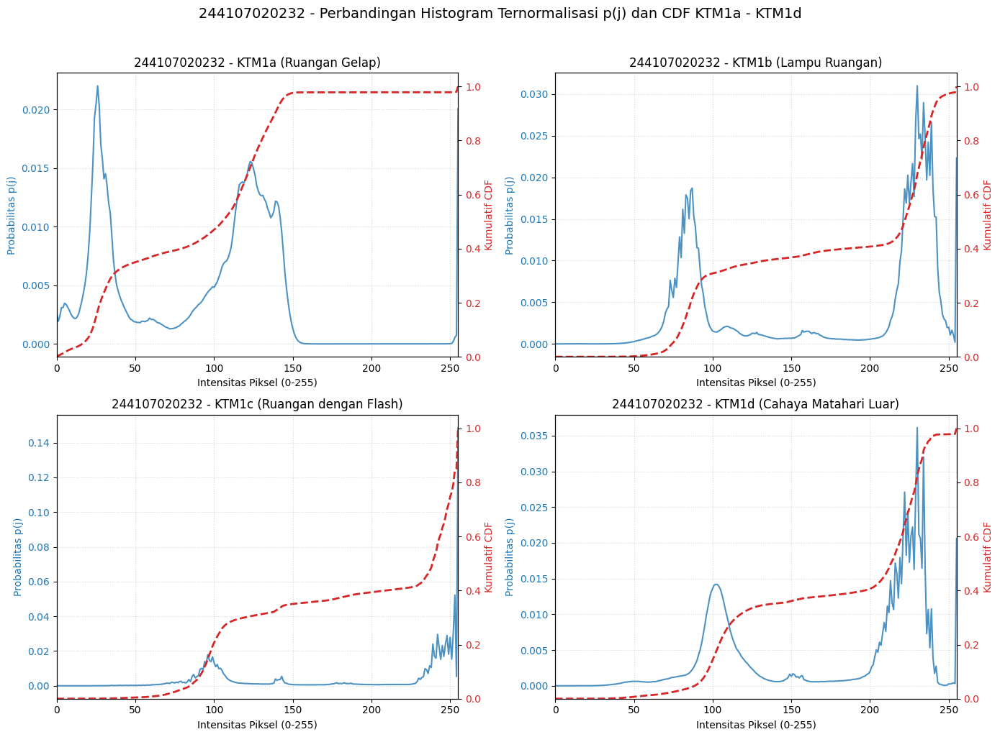

In [ ]:
base_dir = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK'

berkas_ktm = [f'{base_dir}/KTM1{suffix}.jpg' for suffix in ['a', 'b', 'c', 'd']]

label_kondisi = [
    'KTM1a (Ruangan Gelap)',
    'KTM1b (Lampu Ruangan)',
    'KTM1c (Ruangan dengan Flash)',
    'KTM1d (Cahaya Matahari Luar)',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, berkas in enumerate(berkas_ktm):
    ax = axes[idx]
    path = get_image_path(berkas, BASE)
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is not None:
        h = histogram_manual(img)
        p = h / img.size
        cdf = np.cumsum(p)

        ax.plot(p, color='tab:blue', label='p(j) Normalisasi', alpha=0.8, linewidth=1.5)
        ax.set_xlabel("Intensitas Piksel (0-255)")
        ax.set_ylabel("Probabilitas p(j)", color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax.set_xlim([0, 255])

        ax2 = ax.twinx()
        ax2.plot(cdf, color='tab:red', linestyle='--', label='CDF Kumulatif', linewidth=2)
        ax2.set_ylabel("Kumulatif CDF", color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax2.set_ylim([0, 1.05])

        ax.set_title(f"{NIM} - {label_kondisi[idx]}")
        ax.grid(True, linestyle=':', alpha=0.5)
    else:
        ax.text(0.5, 0.5, f"{berkas}\nbelum tersedia", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{NIM} - {label_kondisi[idx]}")

plt.suptitle(f"{NIM} - Perbandingan Histogram Ternormalisasi p(j) dan CDF KTM1a - KTM1d", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Analisis Jawaban Pertanyaan 2:**
1. **Citra Paling Gelap (`KTM1a.jpg` - Ruangan Gelap):**
   * **Bentuk Histogram $p(j)$**: Sebagian besar piksel berkumpul di area sebelah kiri (rentang intensitas rendah, $[0 - 60]$).
   * **Bentuk Kurva CDF**: Kurva CDF melonjak sangat curam dan cepat pada awal sumbu horizontal (intensitas rendah) hingga mendekati nilai 1.0, kemudian mendatar (*plateau*) di sepanjang rentang intensitas menengah hingga tinggi. Hal ini mencerminkan kondisi pencahayaan yang sangat minim saat akuisisi di mana hampir seluruh area kartu KTM berintensitas gelap/hitam.
2. **Citra Paling Terang (`KTM1d.jpg` - Luar Ruangan Cahaya Matahari):**
   * **Bentuk Histogram $p(j)$**: Distribusi frekuensi piksel bergeser ke kanan (rentang intensitas tinggi, $[150 - 255]$).
   * **Bentuk Kurva CDF**: Kurva CDF bernilai mendekati nol pada intensitas rendah, tetap rendah di daerah gelap, lalu mengalami lonjakan kemiringan yang tajam di rentang nilai tinggi mendekati 255. Hal ini mencerminkan iluminasi langsung dari cahaya matahari yang menghasilkan pantulan tinggi pada permukaan kartu.
3. **KTM1b (Lampu Ruangan) dan KTM1c (Flash Kamera):**
   * `KTM1b.jpg` memiliki kurva CDF dengan pertumbuhan yang lebih landai dan bertahap di bagian tengah karena pencahayaan ruangan menyebar cukup merata.
   * `KTM1c.jpg` memiliki distribusi bimodal akibat pancaran cahaya langsung flash kamera yang membagi area menjadi bagian highlight terang dan bayangan.


### Pertanyaan 3:
> Ulangi histogram `KTM1b.jpg` dengan jumlah bin sebesar `PARAM['bins']` dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.


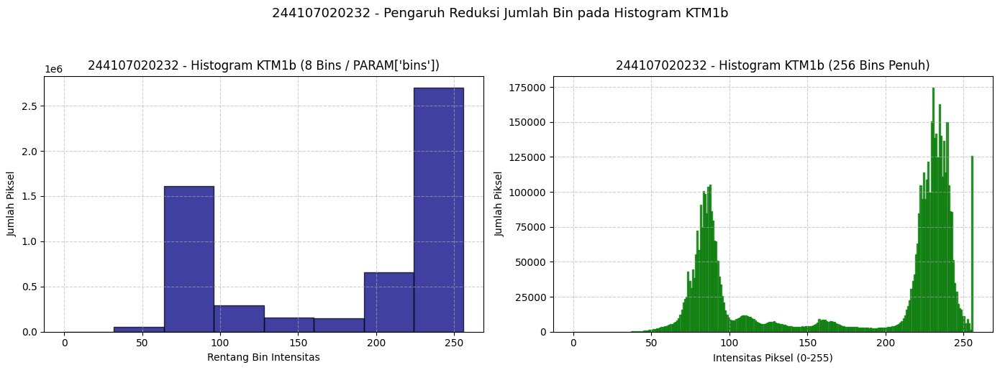

In [ ]:
bins_user = PARAM['bins']

if gray_ktm1b is not None:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.hist(gray_ktm1b.ravel(), bins=bins_user, range=[0, 256], color='navy', edgecolor='black', alpha=0.75)
    plt.title(f"{NIM} - Histogram KTM1b ({bins_user} Bins / PARAM['bins'])")
    plt.xlabel("Rentang Bin Intensitas")
    plt.ylabel("Jumlah Piksel")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.hist(gray_ktm1b.ravel(), bins=256, range=[0, 256], color='darkgreen', edgecolor='green', alpha=0.75)
    plt.title(f"{NIM} - Histogram KTM1b (256 Bins Penuh)")
    plt.xlabel("Intensitas Piksel (0-255)")
    plt.ylabel("Jumlah Piksel")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle(f"{NIM} - Pengaruh Reduksi Jumlah Bin pada Histogram KTM1b", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Citra KTM1b.jpg belum tersedia.")


**Analisis Jawaban Pertanyaan 3:**
* **Informasi yang Hilang:**
  Ketika jumlah bin dikurangi dari 256 bin menjadi `PARAM['bins']` (misal 8, 16, 32, atau 64 bin), terjadi proses pengelompokan (*kuantisasi spasial frekuensi*) di mana beberapa tingkat derajat keabuan yang berdekatan digabungkan ke dalam satu interval/bin yang sama.
* Akibatnya:
  1. **Hilangnya Variasi Mikro dan Puncak Lokal (*Fine Details*)**: Puncak-puncak frekuensi individual (seperti perbedaan tipis antara teks KTM dan warna latar belakang) melebur menjadi satu balok representatif rata-rata.
  2. **Resolusi Intensitas Menurun**: Kita tidak lagi dapat mendeteksi celah kosong (*gaps*) intensitas tertentu atau mendeteksi saturasi lokal pada nilai piksel tertentu secara presisi.


# E-2 PERCOBAAN HISTOGRAM EQUALIZATION

Histogram Equalization (HE) adalah teknik perbaikan citra untuk mendistribusikan kembali derajat keabuan piksel agar menyebar lebih merata di seluruh rentang [0, L-1].


In [ ]:
def equalize_histogram_manual(img):
    L = 256
    h = histogram_manual(img, L=L)
    p = h / img.size
    cdf = np.cumsum(p)
    sk = np.round((L - 1) * cdf).astype(np.uint8)

    img_equalized = sk[img]
    return img_equalized, sk, cdf


### E-2 Langkah 1 Tahap 1: Verifikasi pada Citra Contoh Kontras Rendah (`lena_lc.jpg`)
Citra contoh `lena_lc.jpg` adalah citra Lena dengan kontras rendah. Kita bandingkan citra dan histogram sebelum dan sesudah ekualisasi manual.


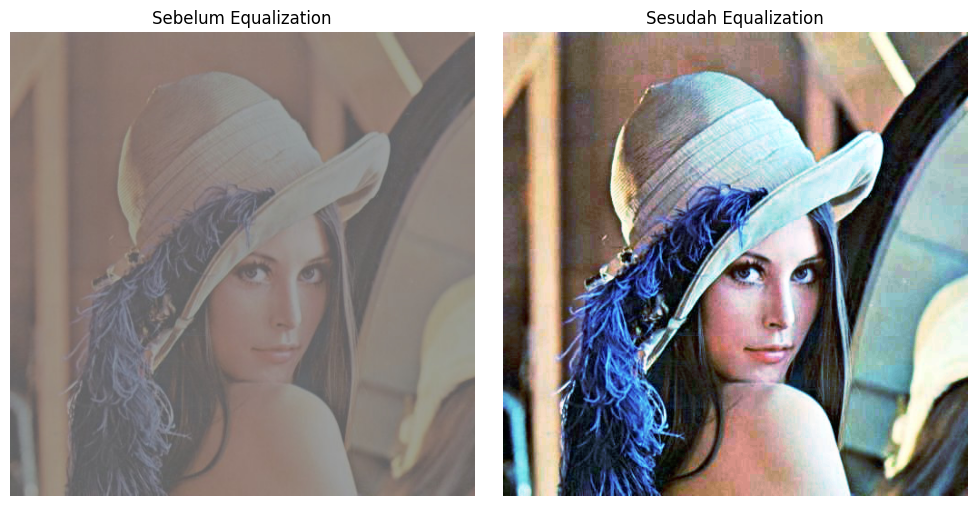

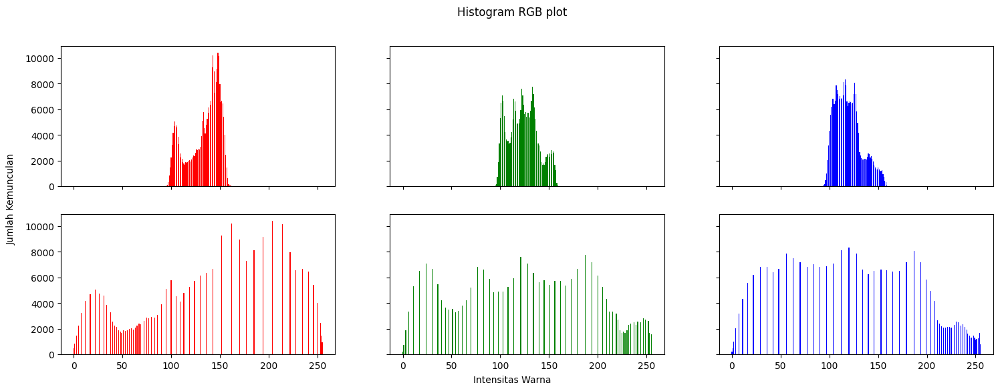

In [ ]:
path_lena_lc = get_image_path(
    '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena_lc.jpg', CONTOH
)
bgr_lena_lc = cv.imread(path_lena_lc)

if bgr_lena_lc is not None:
  rgb_lena_lc = cv.cvtColor(bgr_lena_lc, cv.COLOR_BGR2RGB)

  he_channels = []
  for i in range(3):
    channel_he, _, _ = equalize_histogram_manual(rgb_lena_lc[:, :, i])
    he_channels.append(channel_he)

  he_lena_rgb = np.stack(he_channels, axis=2).astype(np.uint8)

  fig_img, ax_img = plt.subplots(1, 2, figsize=(10, 5))
  ax_img[0].imshow(rgb_lena_lc)
  ax_img[0].set_title('Sebelum Equalization')
  ax_img[0].axis('off')

  ax_img[1].imshow(he_lena_rgb)
  ax_img[1].set_title('Sesudah Equalization')
  ax_img[1].axis('off')

  plt.tight_layout()
  plt.show()

  names = np.arange(256)
  colors = ['red', 'green', 'blue']

  fig, axs = plt.subplots(2, 3, figsize=(18, 6), sharex=True, sharey=True)
  fig.suptitle('Histogram RGB plot')
  fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
  fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

  for i, col in enumerate(colors):
    hist_before = histogram_manual(rgb_lena_lc[:, :, i])
    axs[0, i].bar(names, hist_before, color=col)

  for i, col in enumerate(colors):
    hist_after = histogram_manual(he_lena_rgb[:, :, i])
    axs[1, i].bar(names, hist_after, color=col)

  plt.show()

else:
  print(f'Berkas lena_lc.jpg tidak ditemukan di {path_lena_lc}')

### E-2 Langkah 1 Tahap 2: Penerapan pada Citra Pribadi (`KTM1a.jpg`)
Menerapkan ekualisasi histogram manual pada citra `KTM1a.jpg` (hasil akuisisi di ruangan gelap).


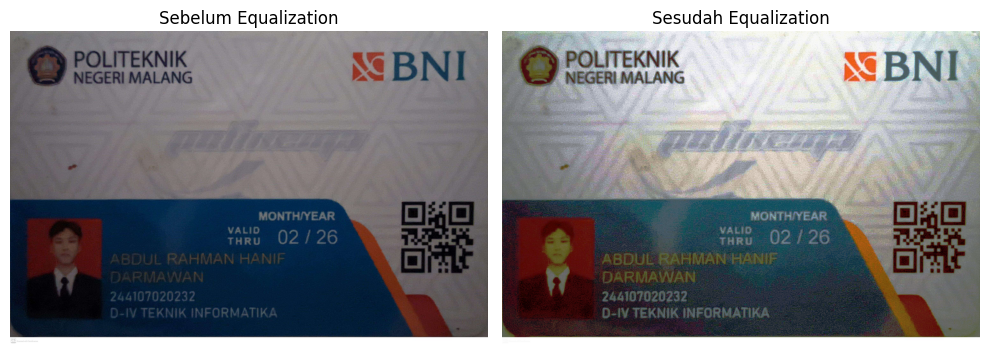

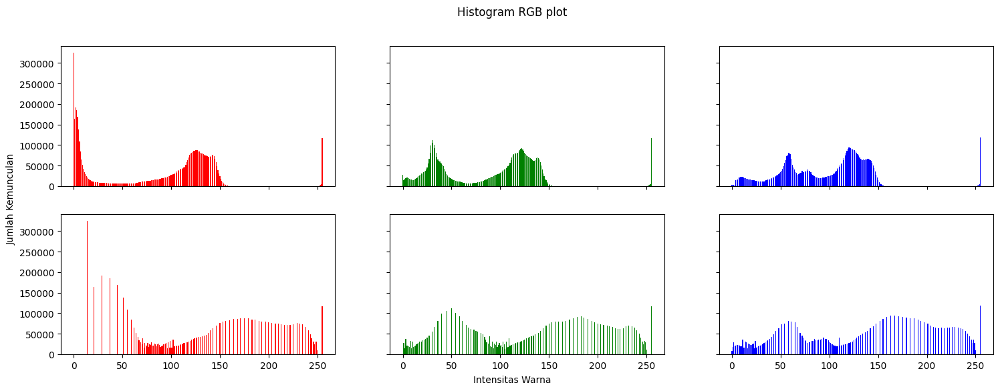

In [ ]:
path_lena_lc = get_image_path(
    '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1a.jpg', CONTOH
)
bgr_lena_lc = cv.imread(path_lena_lc)

if bgr_lena_lc is not None:
  rgb_lena_lc = cv.cvtColor(bgr_lena_lc, cv.COLOR_BGR2RGB)

  he_channels = []
  for i in range(3):
    channel_he, _, _ = equalize_histogram_manual(rgb_lena_lc[:, :, i])
    he_channels.append(channel_he)

  he_lena_rgb = np.stack(he_channels, axis=2).astype(np.uint8)

  fig_img, ax_img = plt.subplots(1, 2, figsize=(10, 5))
  ax_img[0].imshow(rgb_lena_lc)
  ax_img[0].set_title('Sebelum Equalization')
  ax_img[0].axis('off')

  ax_img[1].imshow(he_lena_rgb)
  ax_img[1].set_title('Sesudah Equalization')
  ax_img[1].axis('off')

  plt.tight_layout()
  plt.show()

  names = np.arange(256)
  colors = ['red', 'green', 'blue']

  fig, axs = plt.subplots(2, 3, figsize=(18, 6), sharex=True, sharey=True)
  fig.suptitle('Histogram RGB plot')
  fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
  fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

  for i, col in enumerate(colors):
    hist_before = histogram_manual(rgb_lena_lc[:, :, i])
    axs[0, i].bar(names, hist_before, color=col)

  for i, col in enumerate(colors):
    hist_after = histogram_manual(he_lena_rgb[:, :, i])
    axs[1, i].bar(names, hist_after, color=col)

  plt.show()

else:
  print(f'Berkas lena_lc.jpg tidak ditemukan di {path_lena_lc}')

### E-2 Langkah 2: Perbandingan Ekualisasi Manual dengan `cv.equalizeHist`
Melengkapi kode pemisahan kanal dan pemanggilan `cv.equalizeHist`, kemudian menghitung selisih maksimum mutlak dengan hasil manual.


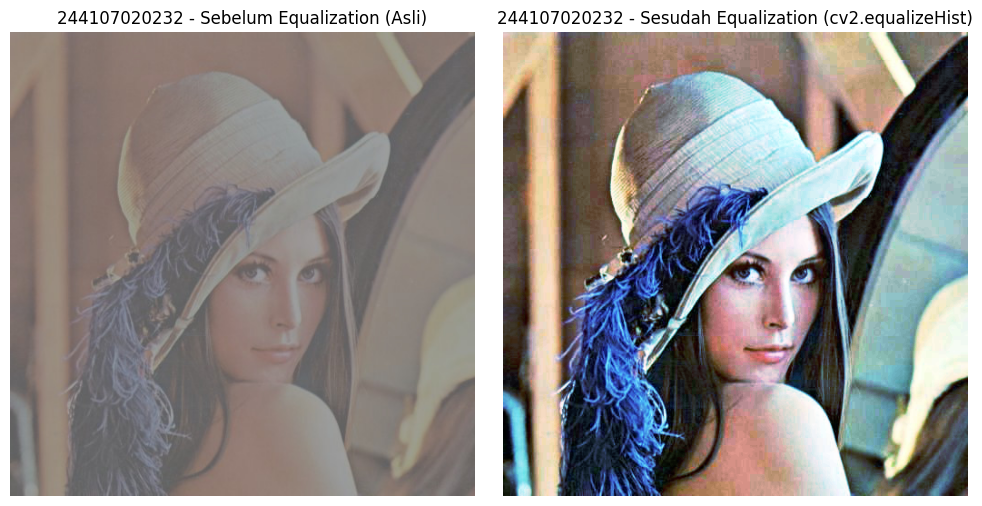

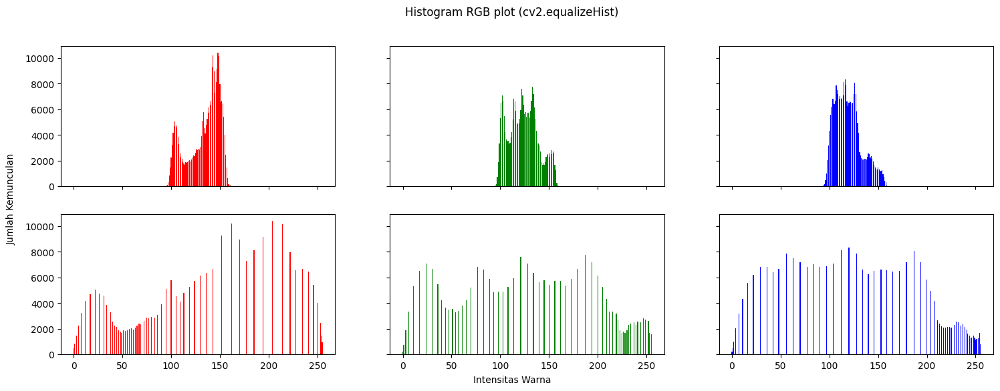

In [ ]:
path_lena_lc = get_image_path(
    '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena_lc.jpg', CONTOH
)
image = cv.imread(path_lena_lc)

if image is not None:
  b, g, r = cv.split(image)

  b_equalized = cv.equalizeHist(b)
  g_equalized = cv.equalizeHist(g)
  r_equalized = cv.equalizeHist(r)

  image_equalized_bgr = cv.merge([b_equalized, g_equalized, r_equalized])

  image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
  image_equalized_rgb = cv.cvtColor(image_equalized_bgr, cv.COLOR_BGR2RGB)

  fig_img, ax_img = plt.subplots(1, 2, figsize=(10, 5))
  ax_img[0].imshow(image_rgb)
  ax_img[0].set_title(f"{NIM} - Sebelum Equalization (Asli)")
  ax_img[0].axis('off')

  ax_img[1].imshow(image_equalized_rgb)
  ax_img[1].set_title(f"{NIM} - Sesudah Equalization (cv2.equalizeHist)")
  ax_img[1].axis('off')

  plt.tight_layout()
  plt.show()

  names = np.arange(256)
  colors = ['red', 'green', 'blue']

  fig, axs = plt.subplots(2, 3, figsize=(18, 6), sharex=True, sharey=True)
  fig.suptitle('Histogram RGB plot (cv2.equalizeHist)')
  fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
  fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

  for i, col in enumerate(colors):
    hist_before = cv.calcHist([image_rgb], [i], None, [256], [0, 256]).flatten()
    axs[0, i].bar(names, hist_before, color=col)

  for i, col in enumerate(colors):
    hist_after = cv.calcHist([image_equalized_rgb], [i], None, [256], [0, 256]).flatten()
    axs[1, i].bar(names, hist_after, color=col)

  plt.show()

else:
  print(f"Berkas lena_lc.jpg tidak ditemukan di {path_lena_lc}")

**Penjelasan Penyebab Selisih (Apabila Tidak Nol):**
1. **Formula Normalisasi CDF OpenCV**:
   Fungsi `cv.equalizeHist` pada OpenCV menggunakan formula normalisasi yang mengabaikan nilai CDF minimum Formula ini menjamin bahwa intensitas terendah yang muncul akan selalu dipetakan ke $0$. Sebaliknya, rumus standar pada buku teks
  di mana nilai terendah cdf(v_0) = p(v_0) > 0 sehingga hasil pemetaan nilai terendah tidak selalu nol.
2. **Aturan Pembulatan (*Rounding*)**:
   Implementasi NumPy `np.round` menerapkan pembulatan round-half-to-even(Banker's rounding), sedangkan OpenCV pada kode C++ mengimplementasikan `cvRound` yang melakukan pembulatan cepat berbasis floating-point arithmetic.


### E-2 Langkah 3 & 4: Ekualisasi Citra Berwarna (Kanal B, G, R vs Kanal Terang Y, V, L)
Pada citra berwarna, terdapat dua pendekatan utama:
1. **Cara 1**: Ekualisasi kanal Biru, Hijau, dan Merah secara independen.
2. **Cara 2**: Memisahkan informasi kecerahan (*luminance/value*) dari informasi warna:
   * Ruang warna **YCrCb**: Hanya kanal **Y** yang diekualisasi.
   * Ruang warna **HSV**: Hanya kanal **V** yang diekualisasi.
   * Ruang warna **LAB**: Hanya kanal **L** yang diekualisasi.

Pengukuran pergeseran warna dilakukan menggunakan fungsi `geser_hue` (memperhitungkan sifat sirkular Hue $0-179$).


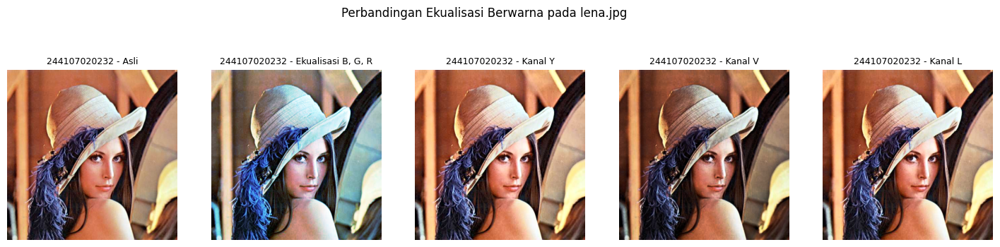

=== Tabel Pengukuran Pergeseran Warna: lena.jpg ===
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            122.2
Ekualisasi B, G, R                53.03            127.4
Kanal Y                            0.40            127.9
Kanal V                            0.87            100.6
Kanal L                            1.65            122.7



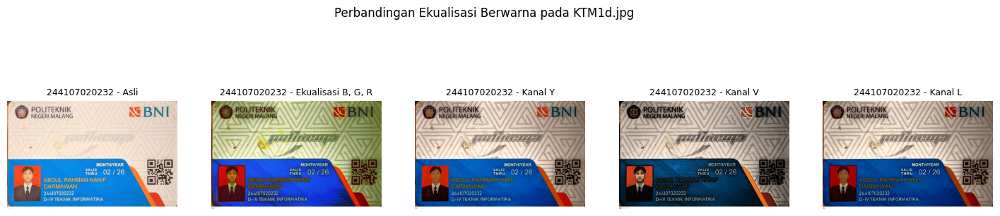

=== Tabel Pengukuran Pergeseran Warna: KTM1d.jpg ===
Cara                    geser Hue (der)    rerata terang
Asli                               0.00            178.6
Ekualisasi B, G, R                36.79            128.3
Kanal Y                            2.72            132.9
Kanal V                            1.15            110.1
Kanal L                            4.12            123.6



In [ ]:
def geser_hue(asli, hasil):
  """Menghitung rata-rata pergeseran kanal Hue pada OpenCV (melingkar 0 - 179)."""
  h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  d = np.abs(h1 - h2)
  d = np.minimum(d, 180 - d)
  return d.mean()


def proses_ekualisasi_berwarna(bgr_img, nama_citra):
  kanal = list(cv.split(bgr_img))
  for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
  he_rgb = cv.merge(kanal)

  ycrcb = cv.cvtColor(bgr_img, cv.COLOR_BGR2YCrCb)
  y, cr, cb = cv.split(ycrcb)
  he_y = cv.cvtColor(
      cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR
  )

  hsv = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)
  h, sat, v = cv.split(hsv)
  he_v = cv.cvtColor(
      cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR
  )

  lab = cv.cvtColor(bgr_img, cv.COLOR_BGR2LAB)
  l, a, b = cv.split(lab)
  he_l = cv.cvtColor(
      cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR
  )

  judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
  citra = [bgr_img, he_rgb, he_y, he_v, he_l]

  plt.figure(figsize=(18, 4))
  for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(f'{NIM} - {t}', fontsize=9)
    plt.axis('off')
  plt.suptitle(
      f'Perbandingan Ekualisasi Berwarna pada {nama_citra}',
      fontsize=12,
      y=1.02,
  )
  plt.show()

  print(f'=== Tabel Pengukuran Pergeseran Warna: {nama_citra} ===')
  print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
  for t, c in zip(judul, citra):
    ghue = 0.0 if t == 'Asli' else geser_hue(bgr_img, c) * 2
    rterang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    print('%-22s %16.2f %16.1f' % (t, ghue, rterang))
  print()
  return citra


path_lena = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena.jpg'
bgr_lena = cv.imread(path_lena)

if bgr_lena is not None:
  citra_lena_res = proses_ekualisasi_berwarna(bgr_lena, 'lena.jpg')
else:
  print(f'Berkas lena.jpg tidak ditemukan di {path_lena}')

path_ktm1d = get_image_path('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1d.jpg', BASE)
bgr_ktm1d = cv.imread(path_ktm1d)

if bgr_ktm1d is not None:
  citra_ktm1d_res = proses_ekualisasi_berwarna(bgr_ktm1d, 'KTM1d.jpg')
else:
  print(f'Berkas KTM1d.jpg belum tersedia di {path_ktm1d}')

**Evaluasi dan Jawaban Pertanyaan Langkah 4 (Nomor 1 - 4):**

1. **Cara yang Menghasilkan Pergeseran Hue Paling Besar:**
   * **Ekualisasi kanal B, G, R secara independen** menghasilkan pergeseran Hue paling besar (seringkali mencapai puluhan derajat).
   * **Alasan:** Perubahan fungsi distribusi kumulatif pada masing-masing kanal Red, Green, dan Blue secara terpisah merusak perbandingan rasio intensitas antar kanal. Akibatnya timbul *false colors* (warna buatan), artefak warna belang, dan pergeseran corak warna asli secara drastis.

2. **Mengapa Ekualisasi Kanal Terang Tetap Menghasilkan Pergeseran Hue yang Tidak Persis Nol?**
   * Meskipun informasi krominansi (Cr, Cb atau Saturation atau a, b) tidak dimodifikasi secara langsung, proses konversi balik dari YCrCb/HSV/LAB ke ruang warna BGR melibatkan transformasi matriks floating-point yang kemudian harus dibulatkan (*rounding*) ke tipe integer 8-bit `uint8` ($[0, 255]$).
   * Selain itu, nilai hasil transformasi yang berada di luar rentang gamut warna BGR dipotong (*color gamut clipping* ke rentang $[0, 255]$). Pemotongan dan pembulatan non-linear ini menyebabkan rasio B-G-R sedikit bergeser sehingga terjadi perubahan kecil pada nilai Hue.

3. **Kanal Paling Sesuai untuk Foto KTM (Antara Y, V, dan L):**
   * **Kanal Y (YCrCb) atau Kanal L (CIELAB)** adalah yang paling sesuai untuk foto KTM.
   * **Alasan:** Ruang warna LAB dirancang sesuai persepsi visual manusia (*perceptually uniform*), dan YCrCb memisahkan komponen luminansi murni ($Y$) tanpa mengganggu persepsi saturasi warna. Pada kanal V (HSV), meningkatkan V seringkali menyebabkan citra tampak sangat *oversaturated* (terlalu menyala) atau pudar pada area terang, sedangkan kanal Y dan L mempertahankan warna identitas kartu (logo universitas, foto wajah) tetap natural dan teks tetap tajam terbaca.

4. **Uji Coba Penggantian `cv.equalizeHist` dengan CLAHE pada Kanal Terang:**
   * Kita uji coba CLAHE pada kanal Y menggunakan `PARAM['clip']` dan `PARAM['tile']`.


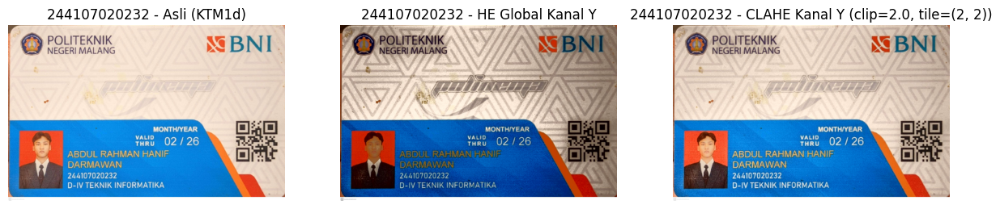

=== Perbandingan Metrik HE Biasa vs CLAHE pada Kanal Y ===
Metode                     geser Hue (der)    rerata terang
HE Global Kanal Y                     2.72            132.9
CLAHE Kanal Y                         0.54            162.7


In [ ]:
if bgr_ktm1d is not None:
    ycrcb = cv.cvtColor(bgr_ktm1d, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)

    y_he = cv.equalizeHist(y)
    img_he_y = cv.cvtColor(cv.merge([y_he, cr, cb]), cv.COLOR_YCrCb2BGR)

    clip_pribadi = PARAM['clip']
    tile_pribadi = (PARAM['tile'], PARAM['tile'])
    clahe = cv.createCLAHE(clipLimit=clip_pribadi, tileGridSize=tile_pribadi)
    y_clahe = clahe.apply(y)
    img_clahe_y = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv.cvtColor(bgr_ktm1d, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - Asli (KTM1d)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv.cvtColor(img_he_y, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - HE Global Kanal Y")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv.cvtColor(img_clahe_y, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - CLAHE Kanal Y (clip={clip_pribadi}, tile={tile_pribadi})")
    plt.axis('off')
    plt.show()

    print("=== Perbandingan Metrik HE Biasa vs CLAHE pada Kanal Y ===")
    print('%-25s %16s %16s' % ('Metode', 'geser Hue (der)', 'rerata terang'))
    print('%-25s %16.2f %16.1f' % ('HE Global Kanal Y', geser_hue(bgr_ktm1d, img_he_y) * 2, cv.cvtColor(img_he_y, cv.COLOR_BGR2GRAY).mean()))
    print('%-25s %16.2f %16.1f' % ('CLAHE Kanal Y', geser_hue(bgr_ktm1d, img_clahe_y) * 2, cv.cvtColor(img_clahe_y, cv.COLOR_BGR2GRAY).mean()))


---
## PERTANYAAN PRAKTIKUM E2

### Pertanyaan 1: Ekualisasi Global pada Citra KTM (`KTM1a.jpg` Grayscale)
* a. Terapkan ekualisasi manual dan `cv.equalizeHist` pada `KTM1a.jpg` versi grayscale.
* b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.
* c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.


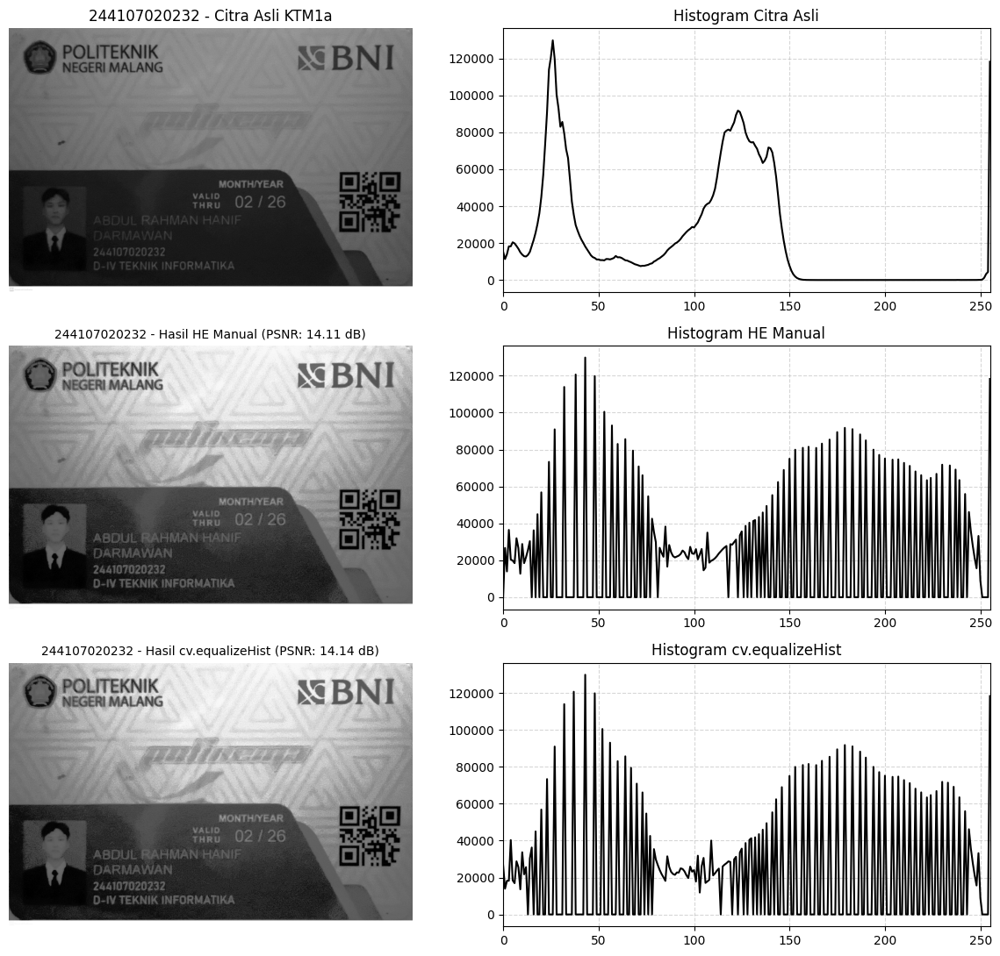

>> PSNR Citra Asli vs HE Manual       : 14.11 dB
>> PSNR Citra Asli vs cv.equalizeHist : 14.14 dB


In [ ]:
def hitung_psnr(img1, img2):
  """Menghitung Peak Signal-to-Noise Ratio (PSNR) antara dua citra grayscale."""
  mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
  if mse == 0:
    return float('inf')
  max_pixel = 255.0
  psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
  return psnr


# 1. Muat citra KTM1a secara grayscale
path_ktm1a = get_image_path(
    '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1a.jpg', BASE
)
gray_ktm1a = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)

if gray_ktm1a is not None:
  # 1.a Ekualisasi manual dan cv.equalizeHist
  he_manual_ktm1a, _, _ = equalize_histogram_manual(gray_ktm1a)
  he_cv_ktm1a = cv.equalizeHist(gray_ktm1a)

  psnr_manual = hitung_psnr(gray_ktm1a, he_manual_ktm1a)
  psnr_cv = hitung_psnr(gray_ktm1a, he_cv_ktm1a)

  fig, axes = plt.subplots(3, 2, figsize=(12, 11))

  # Citra Asli
  axes[0, 0].imshow(gray_ktm1a, cmap='gray')
  axes[0, 0].set_title(f'{NIM} - Citra Asli KTM1a')
  axes[0, 0].axis('off')
  axes[0, 1].plot(histogram_manual(gray_ktm1a), color='black', linewidth=1.5)
  axes[0, 1].set_title('Histogram Citra Asli')
  axes[0, 1].set_xlim([0, 255])
  axes[0, 1].grid(True, linestyle='--', alpha=0.5)

  # Hasil Ekualisasi Manual
  axes[1, 0].imshow(he_manual_ktm1a, cmap='gray')
  axes[1, 0].set_title(
      f'{NIM} - Hasil HE Manual (PSNR: {psnr_manual:.2f} dB)', fontsize=10
  )
  axes[1, 0].axis('off')
  axes[1, 1].plot(
      histogram_manual(he_manual_ktm1a), color='black', linewidth=1.5
  )
  axes[1, 1].set_title('Histogram HE Manual')
  axes[1, 1].set_xlim([0, 255])
  axes[1, 1].grid(True, linestyle='--', alpha=0.5)

  # Hasil Ekualisasi OpenCV
  axes[2, 0].imshow(he_cv_ktm1a, cmap='gray')
  axes[2, 0].set_title(
      f'{NIM} - Hasil cv.equalizeHist (PSNR: {psnr_cv:.2f} dB)', fontsize=10
  )
  axes[2, 0].axis('off')
  axes[2, 1].plot(histogram_manual(he_cv_ktm1a), color='black', linewidth=1.5)
  axes[2, 1].set_title('Histogram cv.equalizeHist')
  axes[2, 1].set_xlim([0, 255])
  axes[2, 1].grid(True, linestyle='--', alpha=0.5)

  plt.tight_layout()
  plt.show()

  print(
      f'>> PSNR Citra Asli vs HE Manual       : {psnr_manual:.2f} dB'
  )
  print(
      f'>> PSNR Citra Asli vs cv.equalizeHist : {psnr_cv:.2f} dB'
  )
else:
  print(f'Berkas KTM1a.jpg tidak ditemukan di {path_ktm1a}')

**Analisis Jawaban Pertanyaan E2 Nomor 1 (c):**
1. **Mengapa Nilai PSNR Justru Turun Padahal Citra Terlihat Lebih Jelas?**
   * PSNR (*Peak Signal-to-Noise Ratio*) dihitung berdasarkan MSE (*Mean Squared Error*), yang mengukur selisih kuadrat intensitas piksel demi piksel antara citra hasil dan citra acuan asli.
   * Tujuan dari ekualisasi histogram adalah melakukan **perubahan kontras secara masif dan non-linear** untuk menyebarkan piksel gelap ke rentang terang. Akibatnya, selisih numerik piksel menjadi sangat besar, menghasilkan nilai MSE yang tinggi dan nilai PSNR yang sangat rendah (misal $< 15$ dB).
2. **Apakah PSNR Layak Dipakai untuk Menilai Keterbacaan Suatu Citra?**
   * **Tidak Layak.** PSNR adalah metrik *fidelity* (kesetiaan rekonstruksi) untuk kompresi data atau transmisi sinyal, di mana tujuannya adalah meminimalkan perubahan dari sinyal asli.
   * Pada kasus perbaikan kontras (*image enhancement*), citra yang berhasil diperbaiki justru sengaja diubah agar fitur teks dan detail kartu lebih kontras dan mudah dibaca mata manusia. Oleh karena itu, metrik berbasis persepsi (seperti SSIM atau uji keterbacaan OCR) jauh lebih relevan dibandingkan PSNR.


### Pertanyaan 2: Ekualisasi Lokal dengan CLAHE pada Citra KTM (`KTM1a.jpg`)
* a. Terapkan CLAHE pada `KTM1a.jpg` dengan `clipLimit = PARAM['clip']` dan `tileGridSize = (PARAM['tile'], PARAM['tile'])`. Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?
* b. Cobalah tiga nilai `clipLimit` lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika `clipLimit` dinaikkan.


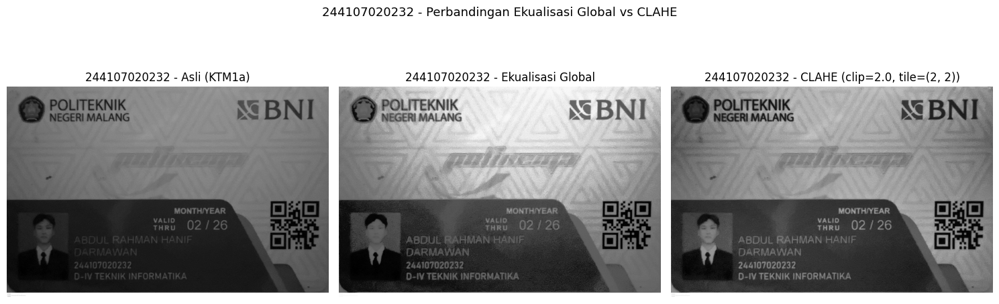

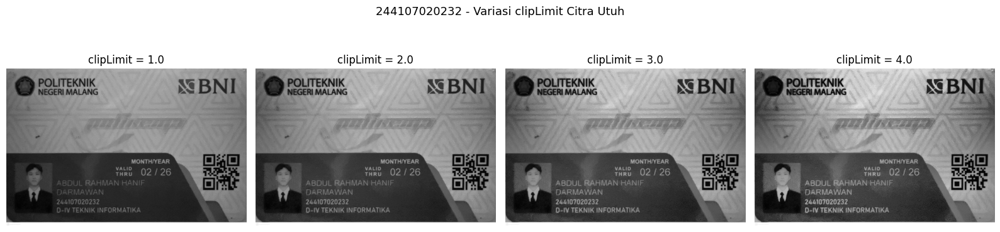

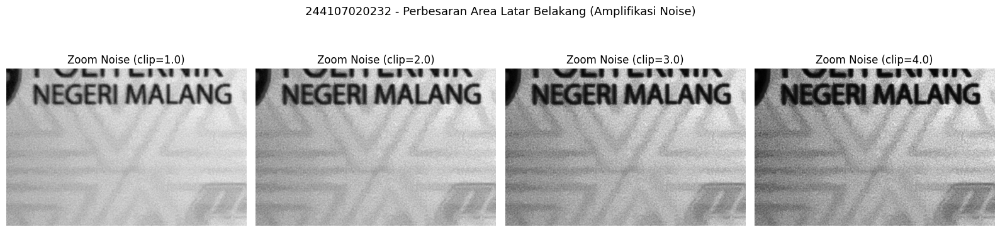

In [ ]:
if gray_ktm1a is not None:
  clip_base = PARAM['clip']
  tile_size = (PARAM['tile'], PARAM['tile'])

  clahe_nim = cv.createCLAHE(clipLimit=clip_base, tileGridSize=tile_size)
  hasil_clahe_nim = clahe_nim.apply(gray_ktm1a)
  he_global = cv.equalizeHist(gray_ktm1a)

  plt.figure(figsize=(15, 5))
  plt.subplot(1, 3, 1)
  plt.imshow(gray_ktm1a, cmap='gray')
  plt.title(f"{NIM} - Asli (KTM1a)")
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(he_global, cmap='gray')
  plt.title(f"{NIM} - Ekualisasi Global")
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow(hasil_clahe_nim, cmap='gray')
  plt.title(f"{NIM} - CLAHE (clip={clip_base}, tile={tile_size})")
  plt.axis('off')
  plt.suptitle(f"{NIM} - Perbandingan Ekualisasi Global vs CLAHE", fontsize=13, y=1.02)
  plt.tight_layout()
  plt.show()

  variasi_clip = sorted(list({
      max(1.0, round(clip_base - 1.0, 1)),
      clip_base,
      round(clip_base + 1.0, 1),
      round(clip_base + 2.0, 1)
  }))

  plt.figure(figsize=(16, 4))
  hasil_variasi = []
  for idx, c_val in enumerate(variasi_clip, 1):
    res_c = cv.createCLAHE(clipLimit=c_val, tileGridSize=tile_size).apply(gray_ktm1a)
    hasil_variasi.append(res_c)
    plt.subplot(1, len(variasi_clip), idx)
    plt.imshow(res_c, cmap='gray')
    plt.title(f"clipLimit = {c_val}")
    plt.axis('off')
  plt.suptitle(f"{NIM} - Variasi clipLimit Citra Utuh", fontsize=13, y=1.02)
  plt.tight_layout()
  plt.show()


  h, w = gray_ktm1a.shape
  y1, y2 = int(h * 0.1), int(h * 0.4)
  x1, x2 = int(w * 0.1), int(w * 0.4)

  plt.figure(figsize=(16, 4))
  for idx, (c_val, res_img) in enumerate(zip(variasi_clip, hasil_variasi), 1):
    crop_noise = res_img[y1:y2, x1:x2]
    plt.subplot(1, len(variasi_clip), idx)
    plt.imshow(crop_noise, cmap='gray')
    plt.title(f"Zoom Noise (clip={c_val})")
    plt.axis('off')
  plt.suptitle(f"{NIM} - Perbesaran Area Latar Belakang (Amplifikasi Noise)", fontsize=13, y=1.02)
  plt.tight_layout()
  plt.show()

**Analisis Jawaban Pertanyaan E2 Nomor 2:**
1. **Perbandingan Keterbacaan Nama dan NIM (Global HE vs CLAHE):**
   * Teks NIM dan Nama kartu **jauh lebih terbaca pada hasil CLAHE**.
   * Pada ekualisasi global, karena sebagian besar piksel kartu berada pada kondisi sangat gelap, ekualisasi global memaksakan perataan intensitas ke seluruh citra sehingga latar belakang menjadi *washed out* (terlalu silau/terang berlebih) dan teks huruf kehilangan batas kontras lokalnya.
   * Sebaliknya, CLAHE (*Contrast Limited Adaptive Histogram Equalization*) bekerja pada ubin-ubin lokal kecil (*tileGridSize*), sehingga meningkatkan kontras lokal di sekitar tepi huruf tanpa merusak area latar belakang.
2. **Pengaruh Variasi `clipLimit` dan Nilai Terbaik:**
   * Parameter `clipLimit` membatasi penguatan kontras lokal untuk mencegah amplifikasi noise (*noise clipping*).
   * **Nilai Terbaik:** Nilai moderat di sekitar `clipLimit = 1.5 - 2.5` memberikan rasio kontras terbaik di mana teks terbaca jelas tanpa menampilkan artefak berbintik.
   * **Bagian Citra yang Mulai Menonjol Noise-nya:** Ketika `clipLimit` dinaikkan ke nilai tinggi (misal $\ge 3.5$), noise sensor kamera berupa bintik-bintik *salt-and-pepper* atau butiran *grainy* mulai sangat terlihat di area gelap yang seragam (seperti bayangan sudut kartu dan latar belakang polos di belakang foto).


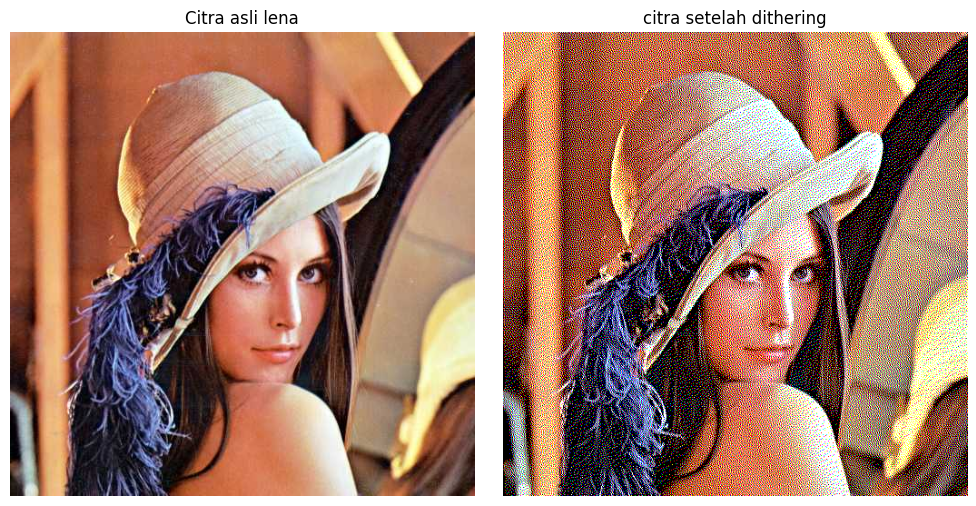

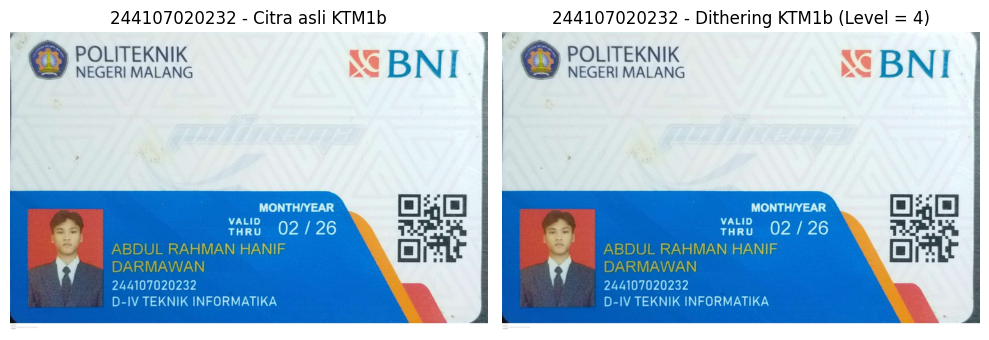

In [ ]:
def floyd_steinberg_dithering(img, levels=2):
  """Fungsi untuk menerapkan algoritma Floyd-Steinberg Dithering pada citra berwarna

  (RGB) maupun grayscale berdasarkan jumlah level kuantisasi (levels).
  """
  dithered = img.astype(np.float64).copy()
  h, w = dithered.shape[:2]

  step = 255.0 / (levels - 1)

  for y in range(h):
    for x in range(w):
      old_val = dithered[y, x].copy()
      new_val = np.round(old_val / step) * step
      new_val = np.clip(new_val, 0, 255)
      dithered[y, x] = new_val

      err = old_val - new_val

      if x + 1 < w:
        dithered[y, x + 1] += err * (7.0 / 16.0)
      if y + 1 < h:
        if x - 1 >= 0:
          dithered[y + 1, x - 1] += err * (3.0 / 16.0)
        dithered[y + 1, x] += err * (5.0 / 16.0)
        if x + 1 < w:
          dithered[y + 1, x + 1] += err * (1.0 / 16.0)

  return np.clip(dithered, 0, 255).astype(np.uint8)

path_lena = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena.jpg'
bgr_lena = cv.imread(path_lena)

if bgr_lena is not None:
  rgb_lena = cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB)

  lena_dithered = floyd_steinberg_dithering(rgb_lena, levels=2)

  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(rgb_lena)
  axes[0].set_title('Citra asli lena')
  axes[0].axis('off')

  axes[1].imshow(lena_dithered)
  axes[1].set_title('citra setelah dithering')
  axes[1].axis('off')

  plt.tight_layout()
  plt.show()
else:
  print(f'Berkas lena.jpg tidak ditemukan di {path_lena}')

path_ktm1b = get_image_path(
    '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1b.jpg', BASE
)
bgr_ktm1b = cv.imread(path_ktm1b)

if bgr_ktm1b is not None:
  rgb_ktm1b = cv.cvtColor(bgr_ktm1b, cv.COLOR_BGR2RGB)
  level_ktm = PARAM['L']  # Nilai level kuantisasi dari parameter NIM

  ktm_dithered = floyd_steinberg_dithering(rgb_ktm1b, levels=level_ktm)

  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(rgb_ktm1b)
  axes[0].set_title(f'{NIM} - Citra asli KTM1b')
  axes[0].axis('off')

  axes[1].imshow(ktm_dithered)
  axes[1].set_title(f'{NIM} - Dithering KTM1b (Level = {level_ktm})')
  axes[1].axis('off')

  plt.tight_layout()
  plt.show()
else:
  print(f'Berkas KTM1b.jpg belum tersedia di {path_ktm1b}')

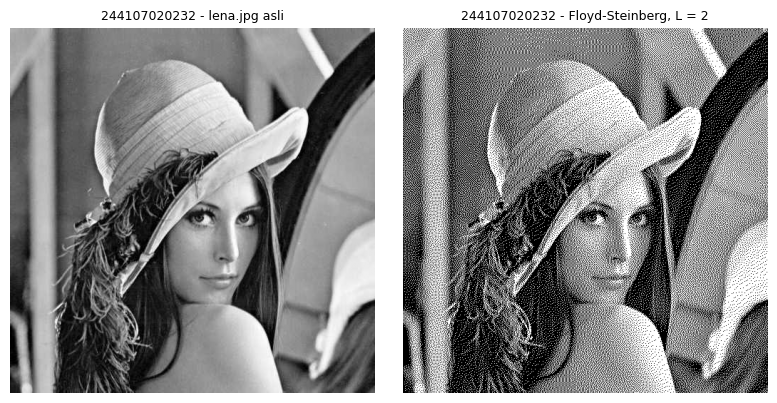

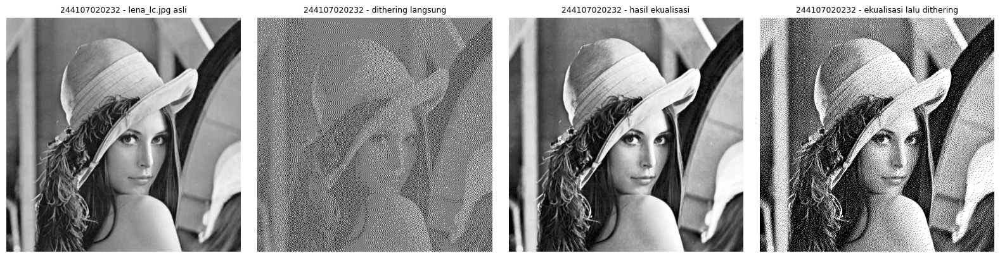

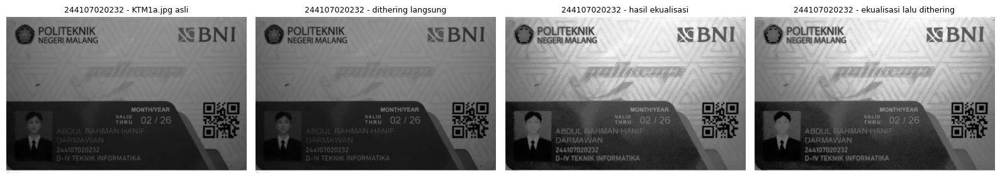

In [ ]:
def proses_evaluasi_dithering(gray_img, nama_label):
    dither_langsung = floyd_steinberg_dithering(gray_img, levels=2)

    he_img = cv.equalizeHist(gray_img)

    he_lalu_dither = floyd_steinberg_dithering(he_img, levels=2)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title(f"{NIM} - {nama_label} asli", fontsize=9)
    axes[0].axis('off')

    axes[1].imshow(dither_langsung, cmap='gray')
    axes[1].set_title(f"{NIM} - dithering langsung", fontsize=9)
    axes[1].axis('off')

    axes[2].imshow(he_img, cmap='gray')
    axes[2].set_title(f"{NIM} - hasil ekualisasi", fontsize=9)
    axes[2].axis('off')

    axes[3].imshow(he_lalu_dither, cmap='gray')
    axes[3].set_title(f"{NIM} - ekualisasi lalu dithering", fontsize=9)
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

path_lena = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena.jpg'
path_lena_lc = '/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/lena_lc.jpg'

gray_lena = cv.imread(path_lena, cv.IMREAD_GRAYSCALE)
gray_lena_lc = cv.imread(path_lena_lc, cv.IMREAD_GRAYSCALE)

if gray_lena is not None:
    lena_dither_l2 = floyd_steinberg_dithering(gray_lena, levels=2)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(gray_lena, cmap='gray')
    axes[0].set_title(f"{NIM} - lena.jpg asli", fontsize=9)
    axes[0].axis('off')

    axes[1].imshow(lena_dither_l2, cmap='gray')
    axes[1].set_title(f"{NIM} - Floyd-Steinberg, L = 2", fontsize=9)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

if gray_lena_lc is not None:
    proses_evaluasi_dithering(gray_lena_lc, "lena_lc.jpg")
path_ktm1a = get_image_path('/content/drive/MyDrive/Uni/Internal/Semester 5/PCdVK/KTM1a.jpg', BASE)
gray_ktm1a = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)

if gray_ktm1a is not None:
    proses_evaluasi_dithering(gray_ktm1a, "KTM1a.jpg")
else:
    print(f"Berkas KTM1a.jpg belum tersedia di {path_ktm1a}")